# Projeto de conversão #

![teste](Imagem_projeto)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator, CubicSpline
from scipy.optimize import brentq
from scipy.integrate import trapezoid

In [2]:
H_tab = np.array([0,68,135,203,271,338,406,474,542,609,1100,1500,2500,4000,5000,9000,12000,20000,25000]) #A/m
B_tab = np.array([0,0.733,1.205,1.424,1.517,1.560,1.588,1.617,1.631,1.646,1.689,1.703,1.724,1.731,1.738,1.761,1.770,1.800,1.816]) # T

mm = 1e-3
cm = 1e-2

alpha =  60                 # Comprimento angular dos polos do rotor e do estator (°) (alpha = beta)
g = 0.45*mm                 # Comprimento do Entreferro
l = 20*cm                   # Comprimento medio do caminho magnetico no nucleo
R = 6.3*cm                  # Raio do rotor
D = 8*cm                    # Comprimento axial da Maquina
N = 90                      # Numero de Espiras da boina
theta_m_inicial = 0         # Posicao angular do rotor em relacao ao estator (°)
Rb = 0.2                    # Resistencia eletrica total da bobina e do sistema de alimentacao (ohms)
J = 0.010                   # Momento de inercia do rotor (kg * m²)

# constantes

u0 = 4*np.pi * 1e-7         # H/m

#### curva BxH ####

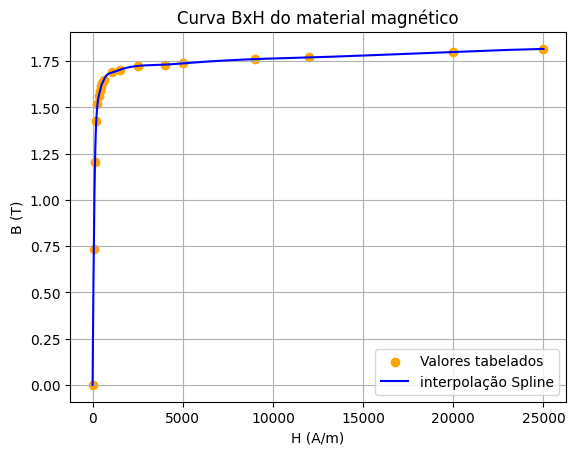

In [3]:
# Interpolação monotônica da curva B x H e de sua inversa.
# A extrapolação acima do último ponto é feita linearmente
# usando a inclinação do último trecho tabelado.

CsH = CubicSpline(H_tab, B_tab)
CsB = CubicSpline(B_tab, H_tab)

cH = CsH.c[2,-1]
dH = CsH.c[3,-1]
cB = CsB.c[2,-1]
dB = CsB.c[3,-1]

def B_de_H(H):
    B = np.where(H>H_tab[-1], cH*(H-H_tab[-2]) + dH, CsH(H))
    return B

def H_de_B(B):
    H = np.where(B>B_tab[-1], cB*(B-B_tab[-2])+dB, CsB(B))
    return H

H_plot = np.linspace(H_tab[0], H_tab[-1], 1001)
B_plot = B_de_H(H_plot)

plt.scatter(H_tab, B_tab, label = 'Valores tabelados', color = 'orange')
plt.plot(H_plot, B_plot, label = 'interpolação Spline', color = 'blue')
plt.grid(True)
plt.title('Curva BxH do material magnético')
plt.legend(loc = 'best')
plt.xlabel('H (A/m)')
plt.ylabel('B (T)')
plt.show()

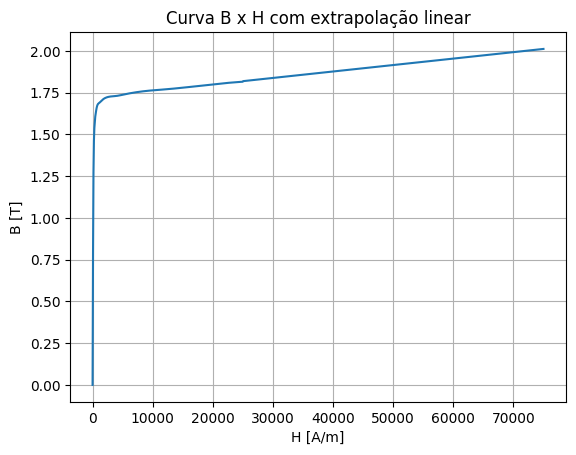

In [4]:
H_teste = np.linspace(0, 3*H_tab[-1], 1001)
B_teste = B_de_H(H_teste)

plt.plot(H_teste, B_teste)
plt.grid(True)
plt.title('Curva B x H com extrapolação linear')
plt.xlabel('H [A/m]')
plt.ylabel('B [T]')
plt.show()


# Etapa 1 #

### Questão 1 ###

In [5]:
A_rotor = np.pi*alpha/180 * R * D

def alpha_sobreposicao(theta):
    """
    Ângulo de sobreposição entre os polos do rotor e do estator.
    Para |theta| >= 60°, a área sobreposta é nula.
    """
    return max(alpha - abs(theta), 0.0)

def Area_entreferro(theta):
    """
    Área efetivamente sobreposta no entreferro.
    """
    alpha_overlap = alpha_sobreposicao(theta)
    return np.pi*alpha_overlap/180 * R * D


def f_H_rotor(H_rotor, I, theta):
    """
    Resíduo da lei de Ampère:
        N I = H_nucleo*l + 2*H_g*g

    A continuidade do fluxo fornece:
        B_g*A_g = B_nucleo*A_rotor
    """
    Ag = Area_entreferro(theta)

    if Ag <= 0:
        return -N*I

    B_rotor = B_de_H(H_rotor)
    B_entreferro = B_rotor*A_rotor/Ag

    queda_nucleo = H_rotor*l
    queda_entreferro = 2*(B_entreferro/u0)*g

    return queda_nucleo + queda_entreferro - N*I


def determina_H_rotor(I, theta):
    """
    Campo magnético no núcleo para uma corrente e posição dadas.
    """
    if I <= 0 or Area_entreferro(theta) <= 0:
        return 0.0

    a = 0.0
    b = H_tab[-1]

    # Expande o limite superior até garantir mudança de sinal.
    while f_H_rotor(b, I, theta) < 0:
        b *= 2.0

    return brentq(lambda H: f_H_rotor(H, I, theta), a, b, xtol=1e-10, rtol=1e-10)


'''
def determina_H_rotor(I, theta):
    
    #Função que calcula o campo magnético no rotor para uma corrente e posição ângular dadas.

    
    def f_H_rotor_H(H_rotor):
        return f_H_rotor(H_rotor, I, theta)

    a = H_tab[0]
    b = H_de_B(2)

    while(np.abs(b-a) > 5e-3):
        c = 0.5*(a+b)
        
        fb = f_H_rotor_H(b)
        fc = f_H_rotor_H(c)

        if fb * fc < 0:
            a = c
        else:
            b = c
        
    return 0.5*(a+b)
'''

def determina_B_rotor(I, theta):
    """
    Densidade de fluxo magnético no núcleo.
    """
    return B_de_H(determina_H_rotor(I, theta))

def Phi_B(I, theta):
    """
    Fluxo magnético no núcleo.
    """
    if I <= 0 or Area_entreferro(theta) <= 0:
        return 0.0
    return determina_B_rotor(I, theta)*A_rotor

def fluxo_concatenado(I, theta):
    """
    Fluxo concatenado lambda = N*Phi.
    """
    return N*Phi_B(I, theta)


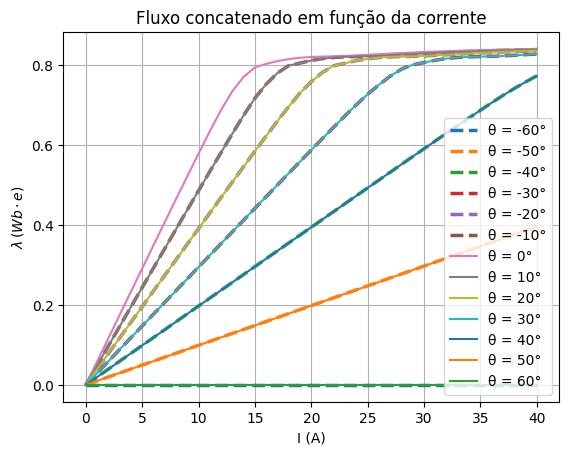

In [6]:
correntes = np.linspace(0,40,41)
angulos = np.arange(-60, 61, 10)

for angulo in angulos:
    fluxo_concatenado_array = np.array([fluxo_concatenado(I, angulo) for I in correntes])

    if angulo < 0:
        plt.plot(correntes, fluxo_concatenado_array, label = f'θ = {angulo}°', linestyle = '--', linewidth = 2.5)
    else:
        plt.plot(correntes, fluxo_concatenado_array, label = f'θ = {angulo}°')
plt.grid(True)
plt.legend(loc = 'lower right')
plt.xlabel('I (A)')
plt.ylabel(r'$\lambda\,(Wb\cdot e)$')
plt.title('Fluxo concatenado em função da corrente')
plt.show()

### Questão 2 ###

In [7]:
def f_I(B_rotor, I, theta):
    """
    Resíduo da lei de Ampère para uma densidade de fluxo definida.
    """
    Ag = Area_entreferro(theta)

    if Ag <= 0:
        raise ValueError("A área de sobreposição é nula.")
    B_entreferro = B_rotor*A_rotor/Ag
    queda_nucleo = H_de_B(B_rotor)*l
    queda_entreferro = 2*(B_entreferro/u0)*g

    return queda_nucleo + queda_entreferro - N*I

def determina_I_para_B(B_rotor, theta):
    """
    Corrente necessária para produzir B_rotor.
    A equação é linear em I depois que B é especificado.
    """
    Ag = Area_entreferro(theta)

    if Ag <= 0:
        raise ValueError("Não é possível produzir fluxo com sobreposição nula.")

    B_entreferro = B_rotor*A_rotor/Ag

    queda_nucleo = H_de_B(B_rotor)*l
    queda_entreferro = 2*(B_entreferro/u0)*g

    return (queda_nucleo + queda_entreferro)/N


In [8]:
B = 1.81 #T
theta = 0

I = determina_I_para_B(B, theta)

print('Para uma densidade de fluxo magnético de %.2f com \u03B8 = %d, deve-se ter I = %.2f A' %(B, theta, I))

Para uma densidade de fluxo magnético de 1.81 com θ = 0, deve-se ter I = 65.29 A


### Questão 3 ###

In [9]:
V = Rb * I

print('A tensão a ser aplicada para gerar uma corrente de %.2f A é de %.2f V' %(I, V))

A tensão a ser aplicada para gerar uma corrente de 65.29 A é de 13.06 V


### Questão 4 ###

A equação que descreve o circuito é

$$V = R\cdot I + \frac{d\lambda(I)}{dt}\,,$$

Realizando uma aproximação por diferenças finitas, tem-se que

$$V=R\cdot I_k + \frac{\lambda(I_k)-\lambda(I_{k-1})}{\Delta t}$$
$$V\cdot\Delta t = R\cdot I_k\cdot\Delta t + \lambda(I_k) - \lambda(I_{k-1})$$
$$\lambda(I_k) - \lambda(I_{k-1}) + R_b\cdot I_k\cdot\Delta t - V\Delta t = 0$$

É a relação recursiva que governa o sistema de maneira aproximada.

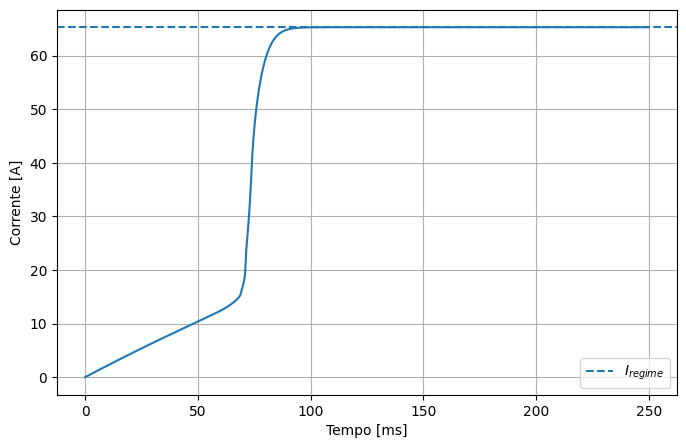

In [10]:
# Passo temporal pequeno para representar adequadamente o transitório
n_pontos = 1001
t = np.linspace(0, 0.25, n_pontos)
dt = t[1] - t[0]

I_regime = V / Rb

def determina_Ik(I_km1, V_eq, I_final, theta, tolerancia=1e-4):
    """
    Resolve a relação recursiva encontrada para determinar a corrente em um instante k
    """
    fluxo_Ikm1 = fluxo_concatenado(I_km1, theta)

    def equacao_discreta(I_k):
        return fluxo_concatenado(I_k, theta) - fluxo_Ikm1 + Rb*I_k*dt - V_eq*dt
        
    a = I_km1
    b = I_final

    fa = equacao_discreta(a)
    fb = equacao_discreta(b)

    if fa*fb > 0:
        raise ValueError(
            "O intervalo escolhido não contém uma raiz: "
            f"f(a)={fa:.4e}, f(b)={fb:.4e}"
        )

    while abs(b-a) > tolerancia:
        c = 0.5*(a+b)
        fb = equacao_discreta(b)
        fc = equacao_discreta(c)

        if fb*fc > 0:
            b = c
        else:
            a = c

    return 0.5*(a+b)

I_array = np.zeros_like(t)

for k in range(1, len(t), 1):
    I_array[k] = determina_Ik(I_array[k-1], V_eq = V, I_final = I_regime,  theta=0)

plt.figure(figsize=(8, 5))
plt.plot(1e3*t, I_array)
plt.axhline(I_regime, linestyle='--', label=r'$I_{regime}$')
plt.xlabel('Tempo [ms]')
plt.ylabel('Corrente [A]')
plt.grid(True)
plt.legend()
plt.show()


I_regime = 65.29 A
0.95*I_regime = 62.03 A
Tempo para atingir 95% = 82.39 ms


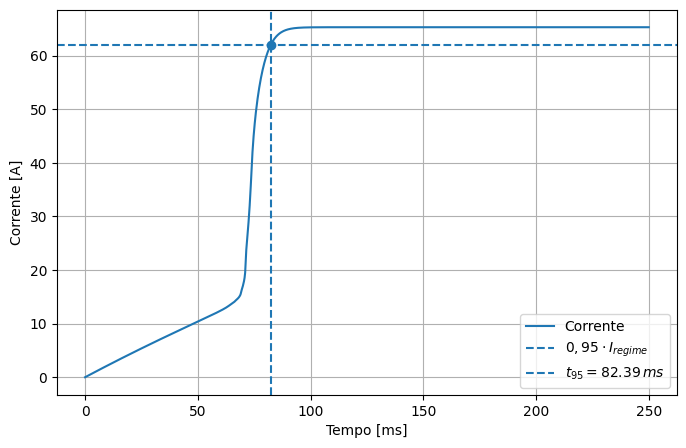

In [11]:
I_95 = 0.95*I_regime

indices = np.where(I_array >= I_95)[0] #Encontra os índices de I_array em que a corrente é maior ou igual a 0.95 do valor em regime permanente

if len(indices) == 0:
    raise RuntimeError(
        "A corrente não atingiu 95% no intervalo simulado."
    )

k_95 = indices[0] #Primeiro valor em que a corrente é maior ou igual a 0.95 da corrente de regime permanente

if I_array[k_95] == I_95:
    t_95 = t[k_95]
else: # Interpolação linear entre os dois pontos que cercam I_95
    t1, t2 = t[k_95 - 1], t[k_95]
    I1, I2 = I_array[k_95 - 1], I_array[k_95]
    t_95 = t1 + (I_95 - I1)*(t2 - t1)/(I2 - I1)

print(f"I_regime = {I_regime:.2f} A")
print(f"0.95*I_regime = {I_95:.2f} A")
print(f"Tempo para atingir 95% = {1e3*t_95:.2f} ms")

plt.figure(figsize=(8, 5))
plt.plot(1e3*t, I_array, label='Corrente')
plt.axhline(I_95, linestyle='--', label=r'$0,95\cdot I_{regime}$')
plt.axvline(1e3*t_95, linestyle='--', label=fr'$t_{{95}}={1e3*t_95:.2f}\,ms$')
plt.scatter([1e3*t_95], [I_95])
plt.xlabel('Tempo [ms]')
plt.ylabel('Corrente [A]')
plt.grid(True)
plt.legend()
plt.show()

### Questão 5 ###

In [12]:
theta = 59
I_seguro = 0.05*I_regime
tempo_limite = t_95/3

V_rev = 0

t_simulacao = np.arange(0, tempo_limite+dt, dt)
fluxo_inicial = fluxo_concatenado(I_regime, theta)
I_array = np.ones_like(t_simulacao)*I_regime

while(True):
    I_array = np.ones_like(t_simulacao)*I_regime
    for k in range(1, len(t_simulacao), 1):
        I_array[k] = determina_Ik(I_array[k-1], V_eq = V_rev, I_final = V_rev/Rb, theta = theta)

    if np.abs(I_array[-1]) > I_seguro:
        V_rev -= 0.1
    else:
        break

print('Tensão reversa necessária: %.2f V ' %(-V_rev))

Tensão reversa necessária: 0.00 V 


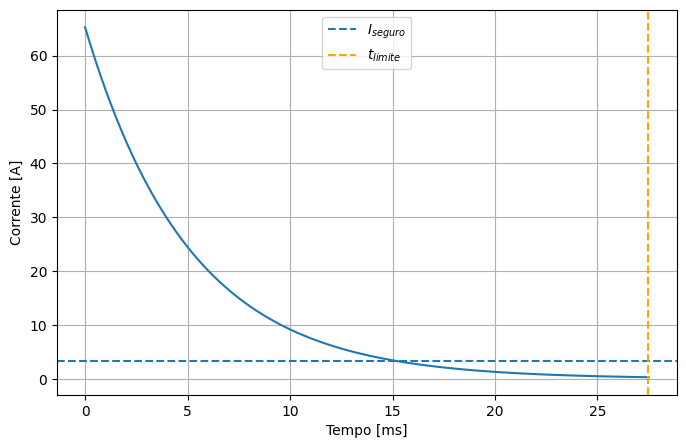

In [13]:
I_array = np.ones_like(t_simulacao)*I_regime

for k in range(1, len(t_simulacao), 1):
    I_array[k] = determina_Ik(I_array[k-1], V_eq = V_rev, I_final = V_rev/Rb,  theta=theta)

plt.figure(figsize=(8, 5))
plt.plot(1e3*t_simulacao, I_array)
plt.axhline(I_seguro, linestyle='--', label=r'$I_{seguro}$')
plt.axvline(tempo_limite*1e3, linestyle='--', label=r'$t_{limite}$', color = 'orange')
plt.xlabel('Tempo [ms]')
plt.ylabel('Corrente [A]')
plt.grid(True)
plt.legend()
plt.show()

### Questão 6 ###

A coenergia é dada por

$$W_c = \int_{0}^{I}\lambda(i,\theta)di\,.$$

Já o torque é dado por

$$\tau = \frac{dWc(\theta)}{d\theta}\,,$$

deseja-se calcular o torque em $\theta = 5^\circ$, para isso, deve-se determinar a coenergia do sistema e aplicar o método das diferenças finitas centrais centrada em $\theta = 5^\circ$.

$$\tau = \frac{W_c(5^\circ + \Delta\theta)-W_c(5^\circ - \Delta\theta)}{2\Delta\theta}$$

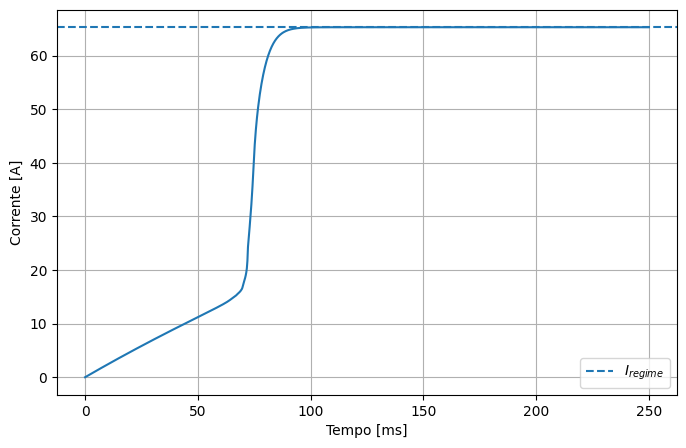

In [14]:
theta = 5
I_array = np.zeros_like(t)
I_regime = V / Rb

# Obtendo a corrente em função do tempo nesta configuração
for k in range(1, len(t), 1):
    I_array[k] = determina_Ik(I_array[k-1], V_eq = V, I_final = I_regime,  theta=theta)

plt.figure(figsize=(8, 5))
plt.plot(1e3*t, I_array)
plt.axhline(I_regime, linestyle='--', label=r'$I_{regime}$')
plt.xlabel('Tempo [ms]')
plt.ylabel('Corrente [A]')
#plt.axhline(I_95, linestyle='--', label=r'$0,95\cdot I_{regime}$')
#plt.axvline(1e3*t_95, linestyle='--', label=fr'$t_{{95}}={1e3*t_95:.2f}\,ms$')
#plt.scatter([1e3*t_95], [I_95])
plt.grid(True)
plt.legend()
plt.show()

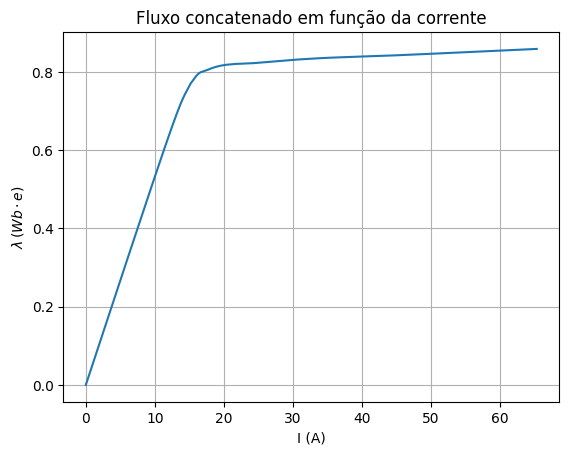

In [15]:
# Calculando o fluxo magnético em função da corrente

fluxo_concatenado_array = np.array([fluxo_concatenado(I, theta) for I in I_array])

plt.plot(I_array, fluxo_concatenado_array)
plt.grid(True)
plt.xlabel('I (A)')
plt.ylabel(r'$\lambda\,(Wb\cdot e)$')
plt.title('Fluxo concatenado em função da corrente')
plt.show()

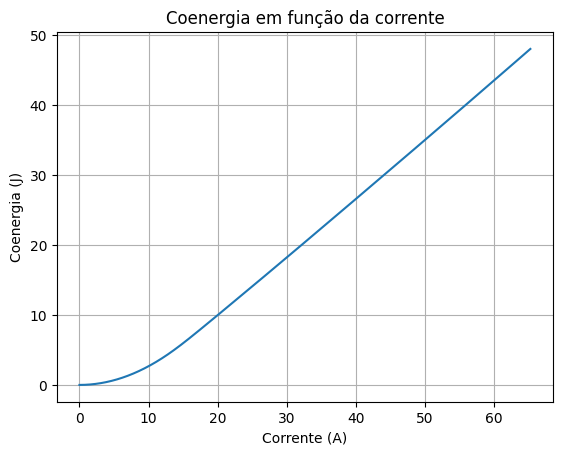

In [16]:
def calcula_coenergia(i_max, theta_graus, n_pontos=201):

    if i_max <= 1e-3:
        return 0.0
    i_grid = np.linspace(0, i_max, n_pontos)
    fluxos = np.array([fluxo_concatenado(x, theta_graus) for x in i_grid])
    return trapezoid(fluxos, i_grid)

Wc_array = np.array([calcula_coenergia(I, theta) for I in I_array])

plt.plot(I_array, Wc_array)
plt.title('Coenergia em função da corrente')
plt.xlabel('Corrente (A)')
plt.ylabel('Coenergia (J)')
plt.grid(True)
plt.show()

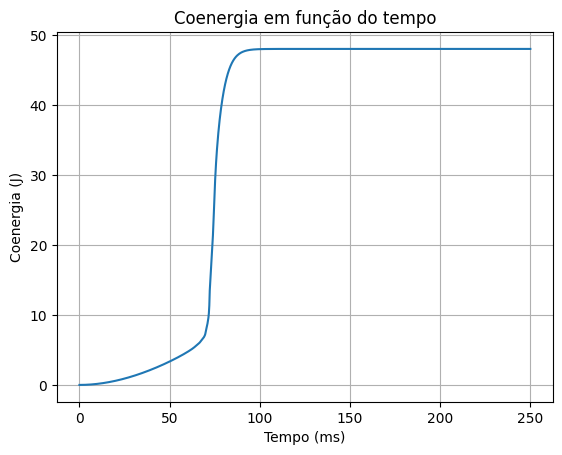

In [17]:
# Coenergia em função do tempo

plt.plot(t*1e3, Wc_array)
plt.title('Coenergia em função do tempo')
plt.xlabel('Tempo (ms)')
plt.ylabel('Coenergia (J)')
plt.grid(True)
plt.show()

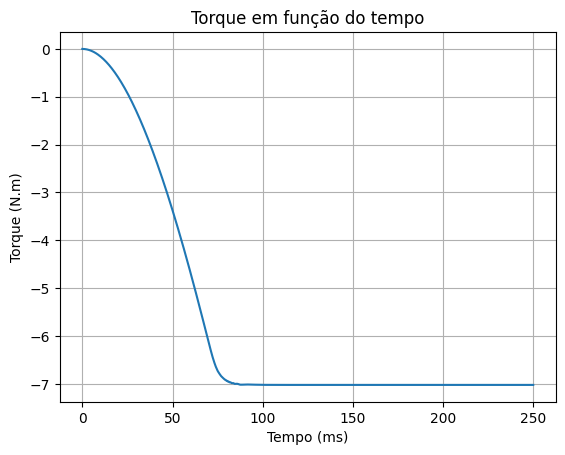

In [18]:
def calcula_torque(i, theta_graus, dtheta_rad=1e-7):
    """
    Calcula o torque usando a derivada da coenergia aproximada por diferenças centrais.
    """
    if i <= 1e-3:
        return 0.0
    
    # Perturbação angular em radianos
    theta_rad = np.radians(theta_graus)
    theta_rad_mais = theta_rad + dtheta_rad
    theta_rad_menos = theta_rad - dtheta_rad
    
    # Conversão de volta para graus
    theta_deg_mais = np.degrees(theta_rad_mais)
    theta_deg_menos = np.degrees(theta_rad_menos)

    W_mais = calcula_coenergia(i, theta_deg_mais)
    W_menos = calcula_coenergia(i, theta_deg_menos)
    
    # Derivada parcial em relação ao ângulo em radianos
    return (W_mais - W_menos) / (2 * dtheta_rad)

torque_array = np.array([calcula_torque(I, theta) for I in I_array])

plt.plot(t*1e3, torque_array)
plt.title('Torque em função do tempo')
plt.xlabel('Tempo (ms)')
plt.ylabel('Torque (N.m)')
plt.grid(True)
plt.show()

# Etapa 2 #

### Questão 1 ###

Considerando os intervalos de desenergização, os intervalos de energização de cada bobina são:

| **Posição do rotor** | **Bobina energizada** |
|:--------------------:|:---------------------:|
| $-45^\circ$ a $44^\circ$   | Bobina 1 |
| $45^\circ$ a $134^\circ$   | Bobina 2 |
| $135^\circ$ a $224^\circ$  | Bobina 1 |
| $225^\circ$ a $314^\circ$  | Bobina 2 |

### Questão 2 ###

O tempo calculado no item 4 se encontra na variável $t_{95}$, então o tempo que cada bobina fica energizada é $t_{on}=2t_{95}$. Nesse período, o rotor percorre uma distância ângular de $\Delta\theta = {89}^\circ$. Como

$$\Delta\theta = \omega_{rotor}\cdot t_{on}\,,$$

então

$$\omega_{rotor} = \frac{\Delta\theta}{t_{on}}\,.$$

O tempo de desenergização da bobina será o tempo para que o rotor percorra uma distância ângular de $1^\circ$.

$$t_{off} = \frac{1^\circ}{\omega_{rotor}}\,.$$

O tempo necessário para que o rotor complete uma volta é

$$t_{1 volta} = 4\cdot(t_{on}+t_{off})$$

In [19]:
delta_theta = 89
t_on = 2*t_95

delta_theta_rad = np.pi*delta_theta/180

omega_rotor = delta_theta_rad/t_on

t_off = (np.pi/180)/omega_rotor #1° = pi/180 rad

print('A velocidade de giro do rotor é %.2f rad/s' %omega_rotor)

t_off = (np.pi/180)/omega_rotor #1° = pi/180 rad

t_1_volta = 4*(t_on + t_off)

A velocidade de giro do rotor é 9.43 rad/s


### Questão 3 ###

Sim, durante alguns instantes após passar pelas posições de alinhamento com as bobinas ($\theta = 0^\circ$, $\theta = 90^\circ$, $\theta = 180^\circ$ e $\theta = 270^\circ$), surge um torque de sentido contrário ao movimento do rotor com a tendência de retorná-lo a posição de alinhamento.

Nas questões subsequêntes, o torque no rotor, assim como outras grandezas, serão quantificadas.

### Questão 4 ###

In [20]:
# Atualizando as funções para ajustá-las ao regime dinâmico permanente

def alpha_sobreposicao_2(theta):
    """
    Ângulo de sobreposição entre os polos do rotor e do estator.
    """

    if theta < 0:
        t = 360 + theta
    else:
        t = theta

    #Se estiver entre 0° e 90°, a bobina 1 esta ativa
    if t < 90:
        alpha_overleap = alpha - np.abs(0 - t)
    #Se estiver entre 90° e 180°, a bobina 2 esta ativa
    elif (t >= 90) and (t < 180):
        alpha_overleap = alpha - np.abs(90 - t)
    #Se estiver entre 180° e 270°, a bobina 1 esta ativa
    elif (t >= 180) and (t < 270):
        alpha_overleap = alpha - np.abs(180 - t)
    #Se estiver entre 270° e 360°, a bobina 2 esta ativa
    else:
       alpha_overleap = alpha - np.abs(270 - t)
    return np.max([alpha_overleap, 0])

def Area_entreferro_2(theta):
    """
    Área efetivamente sobreposta no entreferro.
    """
    alpha_overlap = alpha_sobreposicao_2(theta)
    return np.pi*alpha_overlap/180 * R * D


def f_H_rotor_2(H_rotor, I, theta):
    """
    Resíduo da lei de Ampère:
        N I = H_nucleo*l + 2*H_g*g

    A continuidade do fluxo fornece:
        B_g*A_g = B_nucleo*A_rotor
    """
    Ag = Area_entreferro_2(theta)

    if Ag <= 0:
        return -N*I

    B_rotor = B_de_H(H_rotor)
    B_entreferro = B_rotor*A_rotor/Ag

    queda_nucleo = H_rotor*l
    queda_entreferro = 2*(B_entreferro/u0)*g

    return queda_nucleo + queda_entreferro - N*I


def determina_H_rotor_2(I, theta):
    """
    Campo magnético no núcleo para uma corrente e posição dadas.
    """
    if I <= 0 or Area_entreferro_2(theta) <= 0:
        return 0.0

    a = 0.0
    b = H_tab[-1]

    # Expande o limite superior até garantir mudança de sinal.
    while f_H_rotor_2(b, I, theta) < 0:
        b *= 2.0

    return brentq(lambda H: f_H_rotor_2(H, I, theta), a, b, xtol=1e-10, rtol=1e-10)


def determina_B_rotor_2(I, theta):
    """
    Densidade de fluxo magnético no núcleo.
    """
    return B_de_H(determina_H_rotor_2(I, theta))

def Phi_B_2(I, theta):
    """
    Fluxo magnético no núcleo.
    """
    if I <= 0 or Area_entreferro_2(theta) <= 0:
        return 0.0
    return determina_B_rotor_2(I, theta)*A_rotor

def fluxo_concatenado_2(I, theta):
    """
    Fluxo concatenado lambda = N*Phi.
    """
    return N*Phi_B_2(I, theta)

def determina_Ik_2(I_km1, V_eq, I_final, theta, theta_anterior, tolerancia=1e-4):
    """
    Resolve a relação recursiva encontrada para determinar a corrente em um instante k
    """
    fluxo_Ikm1 = fluxo_concatenado_2(I_km1, theta_anterior)

    def equacao_discreta(I_k):
        return fluxo_concatenado_2(I_k, theta) - fluxo_Ikm1 + Rb*I_k*dt - V_eq*dt
        
    a = I_km1
    b = I_final

    fa = equacao_discreta(a)
    fb = equacao_discreta(b)

    if fa*fb > 0:
        raise ValueError(
            "O intervalo escolhido não contém uma raiz: "
            f"f(a)={fa:.4e}, f(b)={fb:.4e}"
        )

    while abs(b-a) > tolerancia:
        c = 0.5*(a+b)
        fb = equacao_discreta(b)
        fc = equacao_discreta(c)

        if fb*fc > 0:
            b = c
        else:
            a = c

    return 0.5*(a+b)

def calcula_coenergia_2(i_max, theta_graus, n_pontos=201):

    if i_max <= 1e-3:
        return 0.0
    i_grid = np.linspace(0, i_max, n_pontos)
    fluxos = np.array([fluxo_concatenado_2(x, theta_graus) for x in i_grid])
    return trapezoid(fluxos, i_grid)

In [21]:
t_array = np.arange(0, t_1_volta+dt, dt)
theta_inicial = 0

V_rev = 0

theta_array = np.ones_like(t_array)*theta_inicial
for k in range(1, len(theta_array), 1):
    theta_array[k] = theta_array[k-1] + (180*omega_rotor/np.pi)*dt

while(np.any(theta_array > 360)):
    theta_array[theta_array > 360] = theta_array[theta_array > 360] - 360

I_array = np.zeros_like(theta_array)

for k in range(1, len(theta_array), 1):
    theta = theta_array[k]
    theta_anterior = theta # Por algum motivo, theta_anterior = theta_array[k-1] da erro
    try:
        if (theta > 0) and (theta < 89):
            I_array[k] = determina_Ik_2(I_array[k-1], V_eq = V, I_final = V/Rb, theta = theta, theta_anterior = theta_anterior)
        elif (theta >= 89) and (theta < 90):
            I_array[k] = determina_Ik_2(I_array[k-1], V_eq = V_rev, I_final = V_rev/Rb, theta = theta, theta_anterior = theta_anterior)
        elif (theta >= 90) and (theta < 179):
            I_array[k] = determina_Ik_2(I_array[k-1], V_eq = V, I_final = V/Rb, theta = theta, theta_anterior = theta_anterior)
        elif (theta >= 179) and (theta < 180):
            I_array[k] = determina_Ik_2(I_array[k-1], V_eq = V_rev, I_final = V_rev/Rb, theta = theta, theta_anterior = theta_anterior)
        elif (theta >= 180) and (theta < 269):
            I_array[k] = determina_Ik_2(I_array[k-1], V_eq = V, I_final = V/Rb, theta = theta, theta_anterior = theta_anterior)
        elif (theta >= 269) and (theta < 270):
            I_array[k] = determina_Ik_2(I_array[k-1], V_eq = V_rev, I_final = V_rev/Rb, theta = theta, theta_anterior = theta_anterior)
        elif (theta >= 270) and (theta < 359):
            I_array[k] = determina_Ik_2(I_array[k-1], V_eq = V, I_final = V/Rb, theta = theta, theta_anterior = theta_anterior)
        else:
            I_array[k] = determina_Ik_2(I_array[k-1], V_eq = V_rev, I_final = V_rev/Rb, theta = theta, theta_anterior = theta_anterior)
    except:
        print('Iteração do erro: %d' %k)

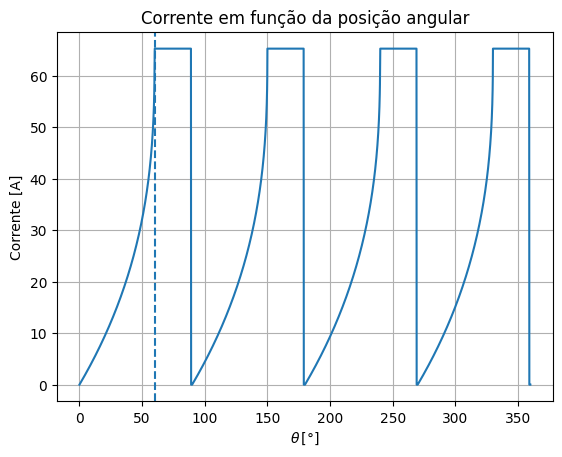

In [22]:
plt.plot(theta_array[:-2], I_array[:-2])
plt.grid(True)
plt.xlabel(r'$\theta\,[°]$')
plt.ylabel('Corrente [A]')
plt.title('Corrente em função da posição angular')
#plt.axvline(90, linestyle = '--')
plt.axvline(60, linestyle = '--')
plt.show()

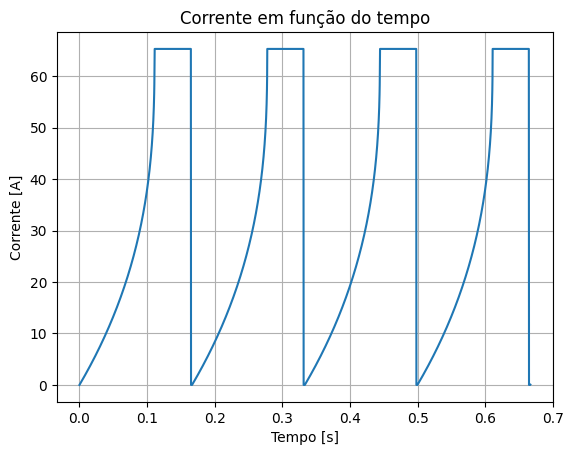

In [23]:
plt.plot(t_array, I_array)
plt.grid(True)
plt.xlabel('Tempo [s]')
plt.ylabel('Corrente [A]')
plt.title('Corrente em função do tempo')
plt.show()

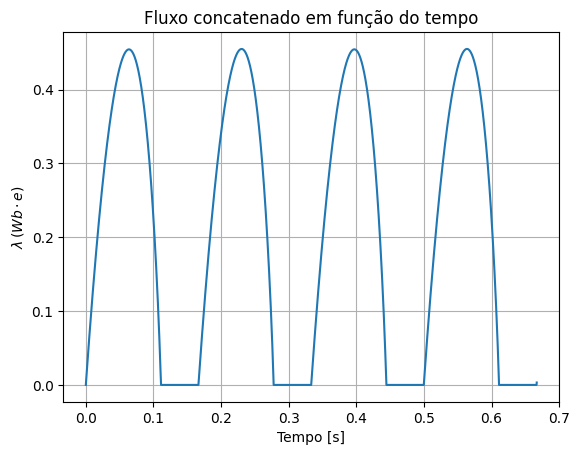

In [24]:
fluxo_concatenado_array = np.array([fluxo_concatenado_2(I_array[k], theta_array[k]) for k in range(len(theta_array))])

plt.plot(t_array, fluxo_concatenado_array)
plt.grid(True)
plt.xlabel('Tempo [s]')
plt.ylabel(r'$\lambda\,(Wb\cdot e)$')
plt.title('Fluxo concatenado em função do tempo')
plt.show()

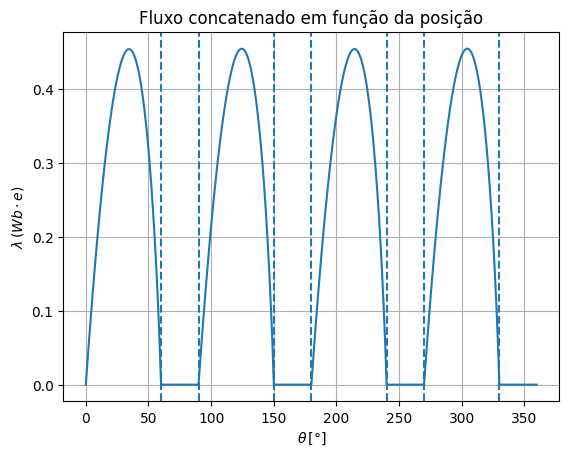

In [25]:
plt.plot(theta_array[:-2], fluxo_concatenado_array[:-2])
plt.grid(True)
plt.xlabel(r'$\theta\,[°]$')
plt.ylabel(r'$\lambda\,(Wb\cdot e)$')
plt.title('Fluxo concatenado em função da posição')
plt.axvline(60, linestyle = '--')
plt.axvline(90, linestyle = '--')
plt.axvline(150, linestyle = '--')
plt.axvline(180, linestyle = '--')
plt.axvline(240, linestyle = '--')
plt.axvline(270, linestyle = '--')
plt.axvline(330, linestyle = '--')
plt.show()

In [26]:
Wc_array = np.array([calcula_coenergia_2(I_array[k], theta_array[k]) for k in range(len(theta_array))])

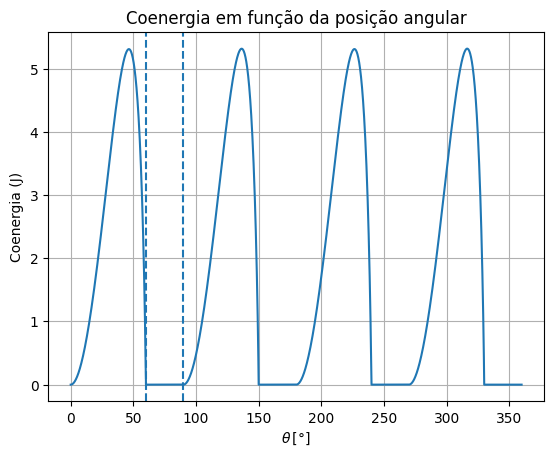

In [27]:
plt.plot(theta_array[:-2], Wc_array[:-2])
plt.grid(True)
plt.xlabel(r'$\theta\,[°]$')
plt.ylabel('Coenergia (J)')
plt.title('Coenergia em função da posição angular')
plt.axvline(60, linestyle = '--')
plt.axvline(90, linestyle = '--')
plt.show()

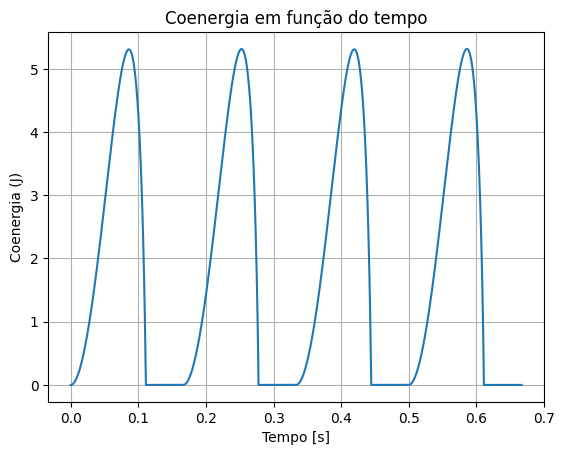

In [28]:
plt.plot(t_array, Wc_array)
plt.grid(True)
plt.xlabel(r'Tempo [s]')
plt.ylabel('Coenergia (J)')
plt.title('Coenergia em função do tempo')
plt.show()

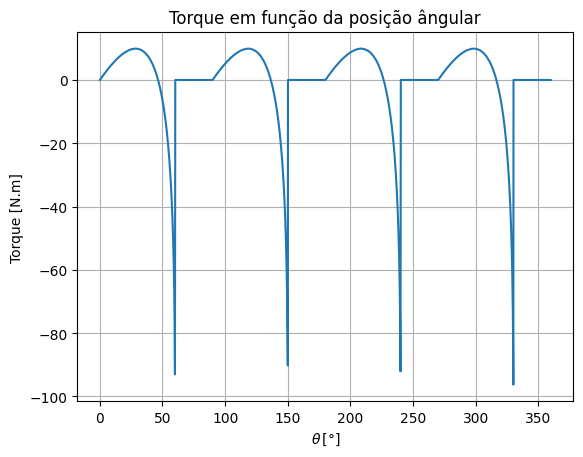

In [29]:
torque_array = np.zeros_like(t_array)
for k in range(1, len(t_array), 1):
    dtheta = theta_array[k] - theta_array[k-1]
    dtheta *= np.pi/180
    torque_array[k] = (Wc_array[k] - Wc_array[k-1]) / dtheta

plt.plot(theta_array[:-2], torque_array[:-2])
plt.xlabel(r'$\theta\,[°]$')
plt.ylabel('Torque [N.m]')
plt.title('Torque em função da posição ângular')
plt.grid(True)
plt.show()

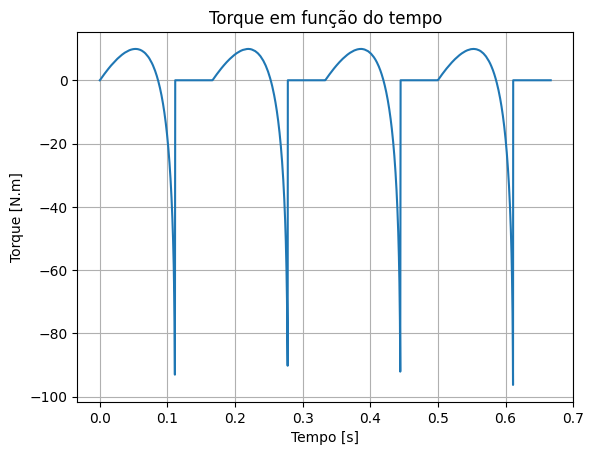

In [30]:
plt.plot(t_array, torque_array)
plt.xlabel('Tempo [s]')
plt.ylabel('Torque [N.m]')
plt.title('Torque em função do tempo')
plt.grid(True)
plt.show()

In [31]:
torque_util = torque_array

# Cálculo do Torque RMS
torque_rms = np.sqrt(np.mean(torque_util**2))

print(f"Torque Eficaz (RMS): {torque_rms:.4f} N.m")

Torque Eficaz (RMS): 12.9454 N.m
